In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:04<00:00, 34.6MB/s]


In [5]:
batch_size = 128

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

In [7]:
def sparsity_penalty(encoded, rho=0.05):

    rho_hat = torch.mean(encoded, dim=0)

    epsilon = 1e-8
    rho_hat = torch.clamp(rho_hat, epsilon, 1 - epsilon)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

In [8]:
criterion = nn.MSELoss()

In [ ]:
best_loss = float('inf')
patience = 3
counter = 0

In [9]:
learning_rates = [0.001, 0.0005, 0.0001]
betas = [0.0001, 0.001, 0.005]

best_loss = float('inf')
best_params = None

In [10]:
for lr in learning_rates:
    for beta in betas:

        print(f"\nTesting LR={lr}, Beta={beta}")

        model = SparseAutoencoder().to(device)

        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=1e-5
        )

        for epoch in range(5):

            total_loss = 0

            for data, _ in trainloader:

                data = data.view(data.size(0), -1).to(device)

                optimizer.zero_grad()

                encoded, decoded = model(data)

                recon_loss = criterion(decoded, data)

                sparse_loss = sparsity_penalty(encoded)

                loss = recon_loss + beta * sparse_loss

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

        print("Loss:", total_loss)

        if total_loss < best_loss:
            best_loss = total_loss
            best_params = (lr, beta)

print("\nBest Learning Rate and Beta:", best_params)


Testing LR=0.001, Beta=0.0001
Loss: inf

Testing LR=0.001, Beta=0.001
Loss: inf

Testing LR=0.001, Beta=0.005
Loss: 73.5486659258604

Testing LR=0.0005, Beta=0.0001
Loss: inf

Testing LR=0.0005, Beta=0.001
Loss: 69.53082908689976

Testing LR=0.0005, Beta=0.005
Loss: 72.79099550843239

Testing LR=0.0001, Beta=0.0001
Loss: inf

Testing LR=0.0001, Beta=0.001
Loss: 74.43636301159859

Testing LR=0.0001, Beta=0.005
Loss: 78.51025012135506

Best Learning Rate and Beta: (0.0005, 0.001)


In [11]:
best_lr, best_beta = best_params

model = SparseAutoencoder().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=best_lr,
    weight_decay=1e-5
)

epochs = 30

In [12]:
for epoch in range(epochs):

    model.train()
    total_loss = 0

    for data, _ in trainloader:

        data = data.view(data.size(0), -1).to(device)

        optimizer.zero_grad()

        encoded, decoded = model(data)

        recon_loss = criterion(decoded, data)

        sparse_loss = sparsity_penalty(encoded)

        loss = recon_loss + best_beta * sparse_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss:.4f}")

Epoch 1/30 Loss: 85.5457
Epoch 2/30 Loss: 73.5978
Epoch 3/30 Loss: 71.3578
Epoch 4/30 Loss: 70.2669
Epoch 5/30 Loss: 69.5218
Epoch 6/30 Loss: 69.1018
Epoch 7/30 Loss: 68.8092
Epoch 8/30 Loss: 68.6015
Epoch 9/30 Loss: 68.4009
Epoch 10/30 Loss: 68.2481
Epoch 11/30 Loss: 68.1224
Epoch 12/30 Loss: 68.0091
Epoch 13/30 Loss: 67.9449
Epoch 14/30 Loss: 67.8201
Epoch 15/30 Loss: 67.7665
Epoch 16/30 Loss: 67.6240
Epoch 17/30 Loss: 67.5444
Epoch 18/30 Loss: 67.4519
Epoch 19/30 Loss: 67.3630
Epoch 20/30 Loss: 67.3144
Epoch 21/30 Loss: 67.2306
Epoch 22/30 Loss: 67.1516
Epoch 23/30 Loss: 67.1254
Epoch 24/30 Loss: 67.0961
Epoch 25/30 Loss: 67.0617
Epoch 26/30 Loss: 67.0130
Epoch 27/30 Loss: 67.0056
Epoch 28/30 Loss: 67.0124
Epoch 29/30 Loss: 66.9679
Epoch 30/30 Loss: 66.9340


In [13]:
model.eval()

test_loss = 0

with torch.no_grad():

    for data, _ in testloader:

        data = data.view(data.size(0), -1).to(device)

        encoded, decoded = model(data)

        loss = criterion(decoded, data)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss)

Test Reconstruction Loss: 13.132238194346428


In [14]:
dataiter = iter(testloader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

encoded, outputs = model(images_flat)

outputs = outputs.view(-1,3,32,32).detach().cpu()
images = images.cpu()

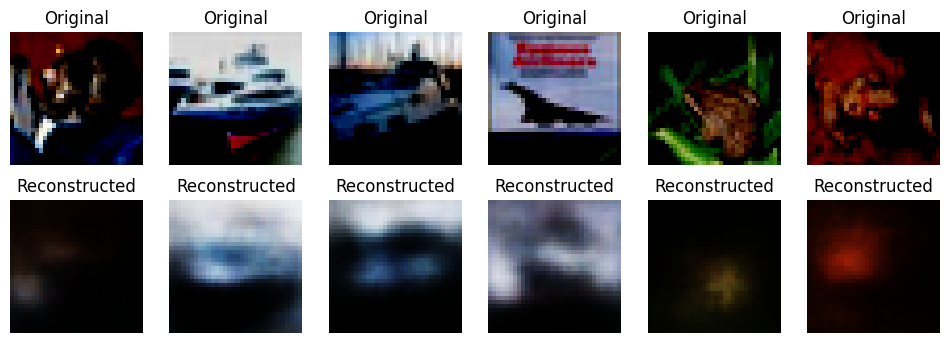

In [15]:
fig, axes = plt.subplots(2,6, figsize=(12,4))

for i in range(6):

    axes[0,i].imshow(images[i].permute(1,2,0))
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(outputs[i].permute(1,2,0))
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()